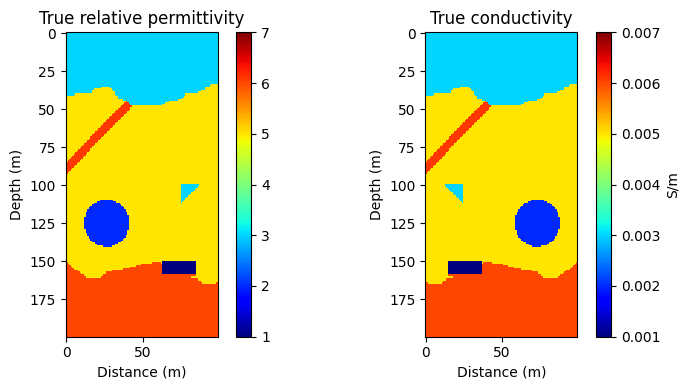

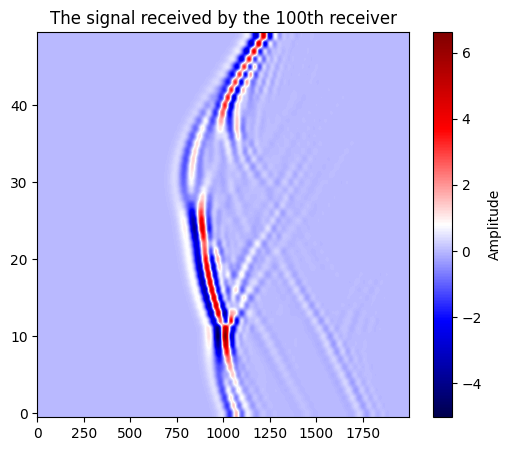

In [1]:
import torch
import torch.nn.functional as F
import numpy as np
import sys 
from pathlib import Path
src_path=Path.cwd().parent / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))
import DeepGPR
import matplotlib.pyplot as plt
from skimage import filters
import time

# Set up the parameters and models
device=torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
dx=0.05
dt=5e-11
nt=2000

source_location=torch.zeros((50,1,3),device=device,dtype=torch.int)
source_location[:,0,0]=torch.arange(10, 210, 4)
source_location[:,:,1]=10

receiver_location=torch.zeros((50,200,3),device=device,dtype=torch.int)
receiver_location[:,:,0]=torch.arange(10, 210, 1).repeat(50,1)
receiver_location[:,:,1]=110


freq=2e8
peak_time = 1 / freq
source_amplitudes = torch.zeros((1,nt,1),device=device)
source_amplitudes[0,:,0]=DeepGPR.ricker(freq, nt, dt, peak_time).to(device)


ert = F.pad(torch.tensor(np.load('2DFWImodel.npy')).unsqueeze(0).unsqueeze(0), pad=(10, 10, 10, 10), mode='replicate').squeeze()
set = ert.clone()*0.001
set[105:, :] = torch.flip(set[105:, :], dims=[1])

fig, axes = plt.subplots(1, 2, figsize=(8, 4))  
im1 = axes[0].imshow(ert[10:-10,10:-10].cpu().numpy(),
                     cmap='jet',
                     interpolation='nearest',
                     aspect='equal',vmax=7,vmin=1)
cbar1 = plt.colorbar(im1, ax=axes[0])
axes[0].set_title('True relative permittivity')
axes[0].set_xlabel('Distance (m)')
axes[0].set_ylabel('Depth (m)')

im2 = axes[1].imshow(set[10:-10,10:-10].cpu().numpy(),
                     cmap='jet',
                     interpolation='nearest',
                     aspect='equal',vmax=0.007,vmin=0.001)
cbar2 = plt.colorbar(im2, ax=axes[1])
cbar2.set_label('S/m')
axes[1].set_title('True conductivity')
axes[1].set_xlabel('Distance (m)')
axes[1].set_ylabel('Depth (m)')

plt.tight_layout()
plt.show()


#Forward modeling
r_obs = DeepGPR.compute(
    device=device, dx=dx, dt=dt, 
    source_amplitudes=source_amplitudes,
    source_location=source_location, 
    receiver_location=receiver_location, 
    er=ert, se=set
)[-1]

plt.figure(figsize=(6, 5)) 
im = plt.imshow(r_obs[:,:,100].detach().cpu().numpy(), cmap='seismic', origin='lower',aspect='auto')
plt.colorbar(im, label='Amplitude') 
plt.title("The signal received by the 100th receiver") 
plt.show()


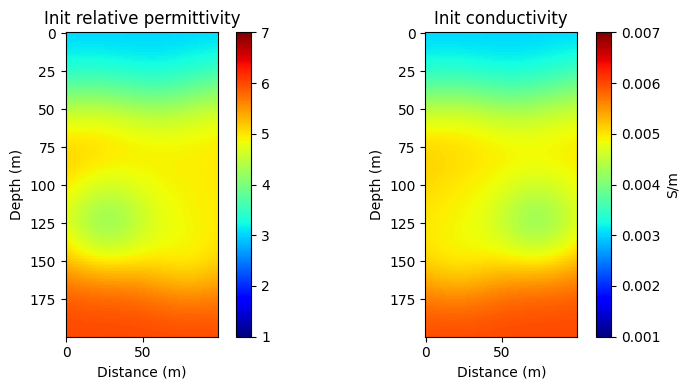

In [2]:
er=torch.tensor(filters.gaussian(ert,sigma=20),device=device)
se=torch.tensor(filters.gaussian(set,sigma=20),device=device)


optimiser_phase1 = torch.optim.Adam([
    {'params': er, 'lr': 0.2},
])

optimiser_phase2 = torch.optim.Adam([
    {'params': er, 'lr': 0.1},
    {'params': se, 'lr': 0.0001}
])
phase1_epochs = 50 
losses = []
n_epochs=201

loss_fnmse = torch.nn.MSELoss()
loss_fnl1= torch.nn.L1Loss()

start_time = time.time()


tv_criterion = DeepGPR.TVRegularization(weight_ep=20,weight_sigma=0.0000000001).to(device)


fig, axes = plt.subplots(1, 2, figsize=(8, 4))  
im1 = axes[0].imshow(er[10:-10,10:-10].cpu().numpy(),
                     cmap='jet',
                     interpolation='nearest',
                     aspect='equal',vmax=7,vmin=1)
cbar1 = plt.colorbar(im1, ax=axes[0])
axes[0].set_title('Init relative permittivity')
axes[0].set_xlabel('Distance (m)')
axes[0].set_ylabel('Depth (m)')

im2 = axes[1].imshow(se[10:-10,10:-10].cpu().numpy(),
                     cmap='jet',
                     interpolation='nearest',
                     aspect='equal',vmax=0.007,vmin=0.001)
cbar2 = plt.colorbar(im2, ax=axes[1])
cbar2.set_label('S/m')
axes[1].set_title('Init conductivity')
axes[1].set_xlabel('Distance (m)')
axes[1].set_ylabel('Depth (m)')

plt.tight_layout()
plt.show()


Epoch 0, Total Loss: 1612276.35 (Data: 1601686.62), Epoch Time: 0.56s, Total Time: 0.86s


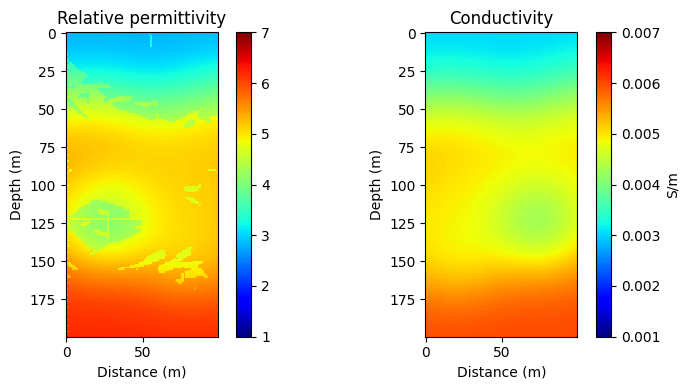

Epoch 1, Total Loss: 1301043.07 (Data: 1274835.50), Epoch Time: 0.52s, Total Time: 1.73s
Epoch 2, Total Loss: 1223343.68 (Data: 1186151.12), Epoch Time: 0.52s, Total Time: 2.25s
Epoch 3, Total Loss: 1165529.26 (Data: 1119070.88), Epoch Time: 0.52s, Total Time: 2.77s
Epoch 4, Total Loss: 1115755.69 (Data: 1061533.50), Epoch Time: 0.53s, Total Time: 3.30s
Epoch 5, Total Loss: 995019.97 (Data: 933959.06), Epoch Time: 0.52s, Total Time: 3.82s
Epoch 6, Total Loss: 940871.15 (Data: 874180.75), Epoch Time: 0.52s, Total Time: 4.35s
Epoch 7, Total Loss: 888644.11 (Data: 818365.12), Epoch Time: 0.52s, Total Time: 4.87s
Epoch 8, Total Loss: 838478.76 (Data: 764665.38), Epoch Time: 0.52s, Total Time: 5.40s
Epoch 9, Total Loss: 788259.78 (Data: 710971.00), Epoch Time: 0.53s, Total Time: 5.92s
Epoch 10, Total Loss: 702596.16 (Data: 622239.25), Epoch Time: 0.52s, Total Time: 6.44s
Epoch 11, Total Loss: 687197.02 (Data: 603185.00), Epoch Time: 0.52s, Total Time: 6.96s
Epoch 12, Total Loss: 679760.12 (

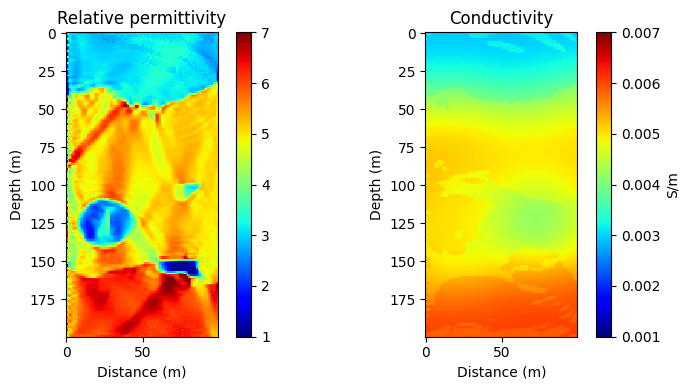

Epoch 51, Total Loss: 862591.23 (Data: 761935.06), Epoch Time: 0.52s, Total Time: 28.20s
Epoch 52, Total Loss: 553649.65 (Data: 455912.62), Epoch Time: 0.53s, Total Time: 28.73s
Epoch 53, Total Loss: 340292.43 (Data: 245085.28), Epoch Time: 0.52s, Total Time: 29.25s
Epoch 54, Total Loss: 503987.85 (Data: 409609.50), Epoch Time: 0.53s, Total Time: 29.78s
Epoch 55, Total Loss: 445009.62 (Data: 353678.50), Epoch Time: 0.52s, Total Time: 30.31s
Epoch 56, Total Loss: 280191.09 (Data: 191993.83), Epoch Time: 0.53s, Total Time: 30.83s
Epoch 57, Total Loss: 367368.84 (Data: 280517.44), Epoch Time: 0.53s, Total Time: 31.36s
Epoch 58, Total Loss: 418894.01 (Data: 333722.12), Epoch Time: 0.53s, Total Time: 31.89s
Epoch 59, Total Loss: 325325.18 (Data: 241682.84), Epoch Time: 0.52s, Total Time: 32.41s
Epoch 60, Total Loss: 229000.19 (Data: 146506.44), Epoch Time: 0.53s, Total Time: 32.94s
Epoch 61, Total Loss: 323003.27 (Data: 240360.53), Epoch Time: 0.53s, Total Time: 33.46s
Epoch 62, Total Loss:

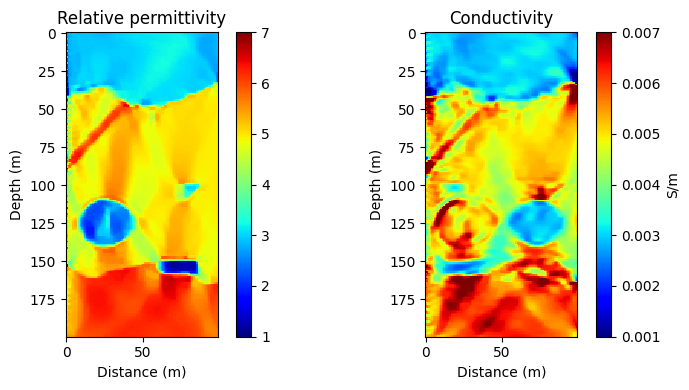

Epoch 101, Total Loss: 120356.21 (Data: 61479.74), Epoch Time: 0.52s, Total Time: 54.75s
Epoch 102, Total Loss: 130847.18 (Data: 72010.68), Epoch Time: 0.53s, Total Time: 55.28s
Epoch 103, Total Loss: 125263.22 (Data: 66906.95), Epoch Time: 0.52s, Total Time: 55.80s
Epoch 104, Total Loss: 129387.41 (Data: 71238.98), Epoch Time: 0.52s, Total Time: 56.33s
Epoch 105, Total Loss: 124607.11 (Data: 67035.30), Epoch Time: 0.52s, Total Time: 56.85s
Epoch 106, Total Loss: 124108.45 (Data: 66598.46), Epoch Time: 0.52s, Total Time: 57.37s
Epoch 107, Total Loss: 131985.71 (Data: 74911.85), Epoch Time: 0.52s, Total Time: 57.90s
Epoch 108, Total Loss: 120065.50 (Data: 63442.73), Epoch Time: 0.52s, Total Time: 58.42s
Epoch 109, Total Loss: 126662.70 (Data: 69901.73), Epoch Time: 0.53s, Total Time: 58.95s
Epoch 110, Total Loss: 124443.91 (Data: 68236.52), Epoch Time: 0.53s, Total Time: 59.48s
Epoch 111, Total Loss: 123319.21 (Data: 67437.08), Epoch Time: 0.53s, Total Time: 60.01s
Epoch 112, Total Loss

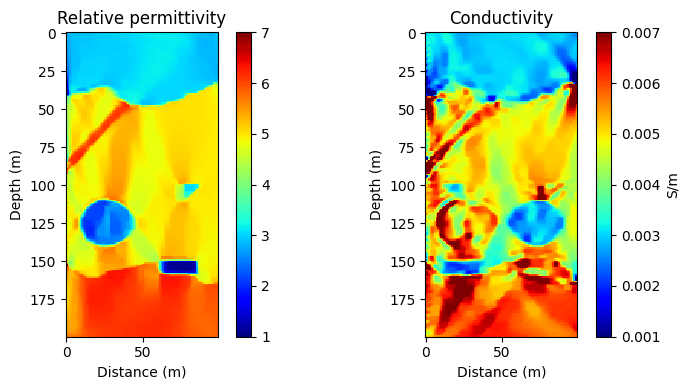

Epoch 151, Total Loss: 111414.98 (Data: 65077.36), Epoch Time: 0.53s, Total Time: 81.80s
Epoch 152, Total Loss: 126082.14 (Data: 79829.33), Epoch Time: 0.54s, Total Time: 82.34s
Epoch 153, Total Loss: 113335.41 (Data: 67346.37), Epoch Time: 0.54s, Total Time: 82.88s
Epoch 154, Total Loss: 130362.55 (Data: 84417.34), Epoch Time: 0.54s, Total Time: 83.42s
Epoch 155, Total Loss: 121876.58 (Data: 76141.59), Epoch Time: 0.56s, Total Time: 83.98s
Epoch 156, Total Loss: 122821.92 (Data: 77245.50), Epoch Time: 0.54s, Total Time: 84.52s
Epoch 157, Total Loss: 120692.61 (Data: 75210.20), Epoch Time: 0.55s, Total Time: 85.07s
Epoch 158, Total Loss: 115461.24 (Data: 70057.69), Epoch Time: 0.55s, Total Time: 85.62s
Epoch 159, Total Loss: 109904.40 (Data: 64651.64), Epoch Time: 0.55s, Total Time: 86.17s
Epoch 160, Total Loss: 123554.13 (Data: 78476.32), Epoch Time: 0.55s, Total Time: 86.72s
Epoch 161, Total Loss: 112083.08 (Data: 67210.51), Epoch Time: 0.54s, Total Time: 87.26s
Epoch 162, Total Loss

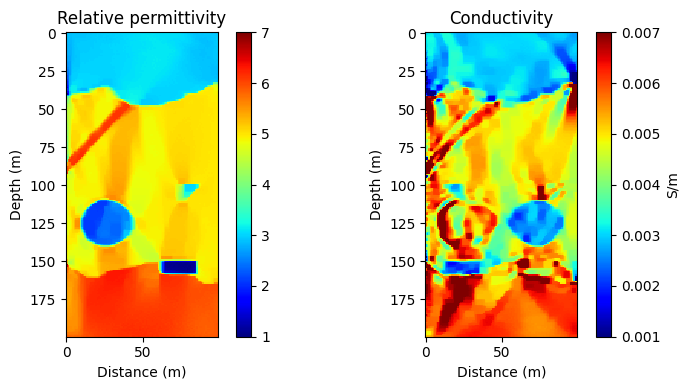

In [3]:

tv_ratio = 0.1 

for epoch in range(n_epochs):
    if epoch < phase1_epochs:
        current_optimizer = optimiser_phase1
        se.requires_grad = False 
        er.requires_grad = True  
    else:
        current_optimizer = optimiser_phase2
        se.requires_grad = True    
        er.requires_grad = True   
    
    epoch_start = time.time()
    
    current_optimizer.zero_grad()

    r = DeepGPR.compute(
        device=device, dx=dx, dt=dt, 
        source_amplitudes=source_amplitudes,
        source_location=source_location, 
        receiver_location=receiver_location, 
        er=er, se=se,model_gradient_sampling_interval=5
    )[-1]
  
    loss_data = loss_fnl1(r, r_obs) * 1e7
    loss_data.backward()

    if er.requires_grad:
        er.grad[:, :10] = 0
        er.grad[:, -10:] = 0
        grad_data_er = er.grad.clone() 
        norm_data_er = torch.norm(grad_data_er) + 1e-8 
        
    if se.requires_grad:
        se.grad[:, :10] = 0
        se.grad[:, -10:] = 0
        grad_data_se = se.grad.clone() 
        norm_data_se = torch.norm(grad_data_se) + 1e-8

    current_optimizer.zero_grad()  
    
    loss_tv = tv_criterion(er, se)
    loss_tv.backward()  

    if er.requires_grad:
        er.grad[:, :10] = 0
        er.grad[:, -10:] = 0
        norm_tv_er = torch.norm(er.grad) + 1e-8
        weight_tv_er = (norm_data_er / norm_tv_er) * tv_ratio
        er.grad = grad_data_er + er.grad * weight_tv_er

    if se.requires_grad:
        se.grad[:, :10] = 0
        se.grad[:, -10:] = 0
        norm_tv_se = torch.norm(se.grad) + 1e-8
        weight_tv_se = (norm_data_se / norm_tv_se) * tv_ratio
        se.grad = grad_data_se + se.grad * weight_tv_se

    current_optimizer.step()
    total_loss = loss_data.item() + loss_tv.item()
    losses.append(total_loss) 
    
    epoch_time = time.time() - epoch_start  
    total_time = time.time() - start_time  
    
    with torch.no_grad():
        se.data.clamp_(min=0)
        er.data.clamp_(min=1)
        
    print(f"Epoch {epoch}, Total Loss: {total_loss:.2f} (Data: {loss_data.item():.2f}), Epoch Time: {epoch_time:.2f}s, Total Time: {total_time:.2f}s")
    
    if epoch % 50 == 0:
        fig, axes = plt.subplots(1, 2, figsize=(8, 4))  
        im1 = axes[0].imshow(er[10:-10,10:-10].detach().cpu().numpy(),
                            cmap='jet',
                            interpolation='nearest',
                            aspect='equal',vmax=7,vmin=1)
        cbar1 = plt.colorbar(im1, ax=axes[0])
        axes[0].set_title('Relative permittivity')
        axes[0].set_xlabel('Distance (m)')
        axes[0].set_ylabel('Depth (m)')

        im2 = axes[1].imshow(se[10:-10,10:-10].detach().cpu().numpy(),
                            cmap='jet',
                            interpolation='nearest',
                            aspect='equal',vmax=0.007,vmin=0.001)
        cbar2 = plt.colorbar(im2, ax=axes[1])
        cbar2.set_label('S/m')
        axes[1].set_title('Conductivity')
        axes[1].set_xlabel('Distance (m)')
        axes[1].set_ylabel('Depth (m)')

        plt.tight_layout()
        plt.show()